In [1]:
import pandas as pd
import numpy as np

In [2]:
# load both weather datasets
# Open-Meteo gives hourly weather data like temperature, humidity, rain, wind, gusts, and dew point
# Meteostat gives daily pressure, which we are adding because pressure is related to rainfall
open_meteo = pd.read_csv('open-meteo.csv')
meteostat = pd.read_csv('meteostat.csv')

open_meteo.head()

,time,temperature_2m (°C),relative_humidity_2m (%),rain (mm),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_gusts_10m (km/h),dew_point_2m (°C)
0,2025-04-01 0:00,17.0,95,4.8,0.5,4.4,16.9,16.1
1,2025-04-01 1:00,16.6,95,4.2,7.2,16.7,19.8,15.8
2,2025-04-01 2:00,16.0,97,5.8,9.7,18.8,18.7,15.5
3,2025-04-01 3:00,15.8,97,3.9,5.2,14.9,19.8,15.2
4,2025-04-01 4:00,15.4,97,2.2,5.6,13.8,10.4,14.9


In [3]:
# convert time columns into datetime format so we can work with dates properly
open_meteo['time'] = pd.to_datetime(open_meteo['time'])
meteostat['date'] = pd.to_datetime(meteostat['date'])

# create a date-only column so both datasets can be matched
open_meteo['date_only'] = open_meteo['time'].dt.date
meteostat['date_only'] = meteostat['date'].dt.date

In [4]:
# convert hourly open-meteo data into daily averages
# this is necessary because meteostat data is daily
daily_open = open_meteo.groupby('date_only').mean(numeric_only=True).reset_index()

daily_open.head()

,date_only,temperature_2m (°C),relative_humidity_2m (%),rain (mm),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_gusts_10m (km/h),dew_point_2m (°C)
0,2025-04-01,10.183333,66.208333,1.033333,14.629167,24.012500,34.912500,3.487500
1,2025-04-02,4.754167,55.250000,0.000000,12.500000,22.550000,27.912500,-3.550000
2,2025-04-03,12.916667,85.208333,0.129167,14.112500,26.341667,32.633333,10.429167
3,2025-04-04,18.779167,70.333333,0.300000,12.470833,22.429167,29.575000,12.591667
4,2025-04-05,10.770833,70.250000,0.058333,12.404167,23.570833,27.275000,5.433333


In [5]:
# merge datasets to include pressure from meteostat
df = pd.merge(
    daily_open,
    meteostat[['date_only', 'pres']],
    on='date_only',
    how='inner'
)

df.head()

,date_only,temperature_2m (°C),relative_humidity_2m (%),rain (mm),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_gusts_10m (km/h),dew_point_2m (°C),pres
0,2025-04-01,10.183333,66.208333,1.033333,14.629167,24.012500,34.912500,3.487500,1013.7
1,2025-04-02,4.754167,55.250000,0.000000,12.500000,22.550000,27.912500,-3.550000,1030.5
2,2025-04-03,12.916667,85.208333,0.129167,14.112500,26.341667,32.633333,10.429167,1019.0
3,2025-04-04,18.779167,70.333333,0.300000,12.470833,22.429167,29.575000,12.591667,1020.6
4,2025-04-05,10.770833,70.250000,0.058333,12.404167,23.570833,27.275000,5.433333,1023.0


In [6]:
# remove rows with missing values
df = df.dropna()

# convert rain amount into a binary value
# 0 means no rain, 1 means rain
df['rain_binary'] = (df['rain (mm)'] > 0).astype(int)

In [7]:
# select features for the model
# includes temperature, humidity, wind speeds at different heights, gusts, dew point, and pressure
features = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'wind_speed_10m (km/h)',
    'wind_speed_100m (km/h)',
    'wind_gusts_10m (km/h)',
    'dew_point_2m (°C)',
    'pres'
]

X = df[features]
y = df['rain_binary']

In [8]:
# show summary statistics so we can understand the range of each variable
description = df[features + ['rain_binary']].describe(include='all')
print(description)

       temperature_2m (°C)  relative_humidity_2m (%)  wind_speed_10m (km/h)  \
count           183.000000                183.000000             183.000000   
mean             20.353119                 67.431466               9.716872   
std               5.776479                 12.975460               3.594665   
min               2.716667                 37.666667               3.504167   
25%              17.516667                 58.666667               7.285417   
50%              20.762500                 66.375000               9.120833   
75%              24.537500                 77.333333              11.635417   
max              33.445833                 94.750000              22.912500   

       wind_speed_100m (km/h)  wind_gusts_10m (km/h)  dew_point_2m (°C)  \
count              183.000000             183.000000         183.000000   
mean                17.202254              23.148087          13.315779   
std                  5.829012               7.285637           

In [9]:
# split the data into training and testing sets
# training data teaches the model
# testing data lets us compare model predictions later
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50
)

In [10]:
# scale the features using StandardScaler (mean = 0, std = 1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# train the logistic regression model
# logistic regression is used because the output is binary: rain or no rain
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
# print coefficients to understand feature impact
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[-0.33399197  1.89762898  0.13651077 -0.83560883  1.09580178  0.65968796
  -0.32361818]]
Intercept: [0.63831296]


In [13]:
# test the model with a new weather example
temp = 10
humidity = 80
wind_speed_10m = 15
wind_speed_100m = 25
gusts = 30
dew_point = 7
pressure = 1015

new_weather = pd.DataFrame(
    [[temp, humidity, wind_speed_10m, wind_speed_100m, gusts, dew_point, pressure]],
    columns=features
)

# scale the new data using the same scaler
new_weather_scaled = scaler.transform(new_weather)

prediction = model.predict(new_weather_scaled)
probability = model.predict_proba(new_weather_scaled)

print("Prediction:", prediction[0])
print("Probability of rain:", probability[0][1])

if prediction[0] == 1:
    print("Rain")
else:
    print("No Rain")

Prediction: 1
Probability of rain: 0.9192739672674923
Rain


In [14]:
# compare predictions with actual values
y_pred = model.predict(X_test_scaled)

results = pd.DataFrame({
    'Actual Rain': y_test,
    'Predicted Rain': y_pred
})

print(results)

     Actual Rain  Predicted Rain
21             1               0
49             0               0
161            0               0
35             1               1
26             1               0
124            0               0
58             1               1
147            0               0
77             1               1
139            1               1
120            1               0
121            1               1
8              0               0
12             1               1
173            0               0
74             1               1
25             1               1
183            0               0
144            0               0
89             1               1
84             0               0
171            0               0
108            0               0
152            0               0
166            0               0
39             0               1
62             0               0
126            0               0
24             0               0
125       

In [15]:
# evaluate the model using classification metrics AND log loss together
# accuracy = overall correctness
# precision = how many predicted rain days were actually rain
# recall = how many actual rain days were correctly found
# F1-score = balance between precision and recall
# log loss = evaluates how good the predicted probabilities are

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# log loss (uses probabilities instead of predictions)
probs = model.predict_proba(X_test_scaled)
loss = log_loss(y_test, probs)

# print everything nicely
print("=== Model Evaluation ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Log Loss:  {loss:.4f}")

print("\nConfusion Matrix:")
print(cm)

=== Model Evaluation ===
Accuracy:  0.8649
Precision: 0.8333
Recall:    0.7692
F1-score:  0.8000
Log Loss:  0.3584

Confusion Matrix:
[[22  2]
 [ 3 10]]


In [16]:
# show how important each feature is according to the coefficient
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

# sort by importance (largest effect first)
feature_importance['Abs Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs Coefficient', ascending=False)

print(feature_importance)

                    Feature  Coefficient  Abs Coefficient
1  relative_humidity_2m (%)     1.897629         1.897629
4     wind_gusts_10m (km/h)     1.095802         1.095802
3    wind_speed_100m (km/h)    -0.835609         0.835609
5         dew_point_2m (°C)     0.659688         0.659688
0       temperature_2m (°C)    -0.333992         0.333992
6                      pres    -0.323618         0.323618
2     wind_speed_10m (km/h)     0.136511         0.136511


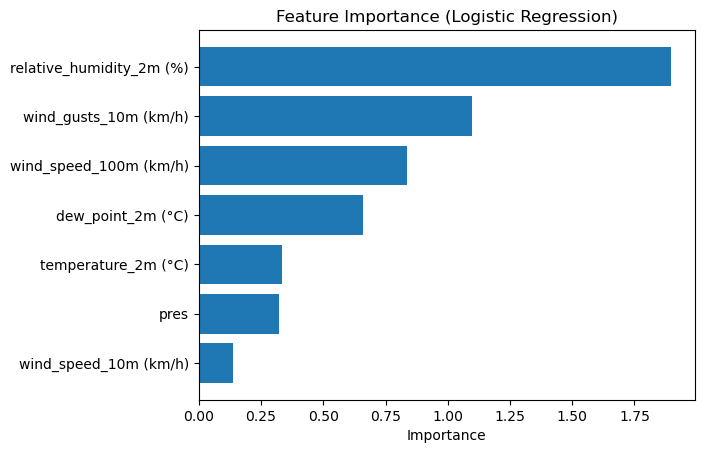

In [17]:
import matplotlib.pyplot as plt

plt.barh(feature_importance['Feature'], feature_importance['Abs Coefficient'])
plt.xlabel("Importance")
plt.title("Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()

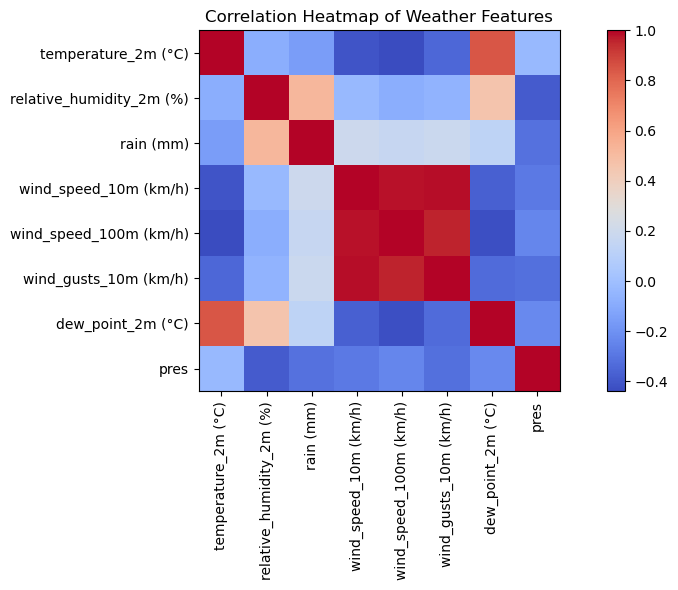

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# correlation matrix
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10,6))

# create heatmap
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

# add labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap of Weather Features")
plt.tight_layout()
plt.show()

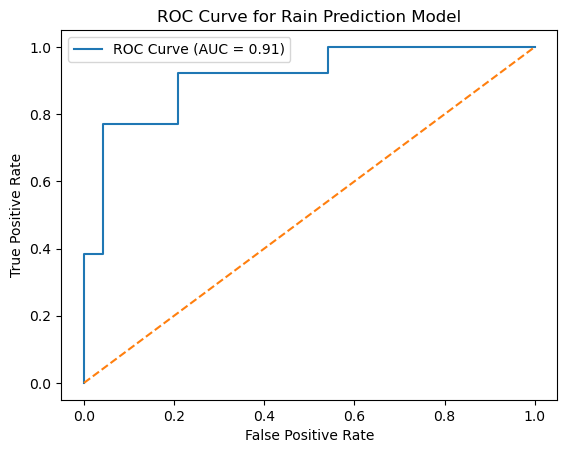

In [19]:
from sklearn.metrics import roc_curve, auc

# get probabilities for positive class (rain = 1)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# compute AUC
roc_auc = auc(fpr, tpr)

# plot
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Rain Prediction Model")
plt.legend()
plt.show()

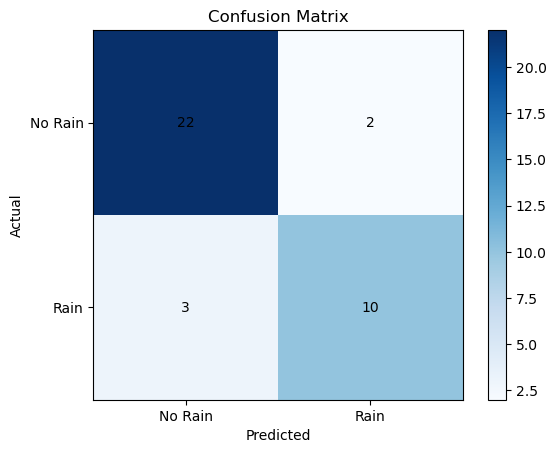

In [20]:


# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot it
plt.imshow(cm, cmap='Blues')
plt.colorbar()

# labels
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

# tick labels
plt.xticks([0,1], ["No Rain", "Rain"])
plt.yticks([0,1], ["No Rain", "Rain"])

plt.show()